In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity

In [2]:
import emcee
import pandas as pd
from astropy.table import Table
import corner
import scipy

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


# L11

### Data

In [3]:
file='transient.npy'
data=np.load(file)
N=10
t=data[:,0]
flux=data[:,1]
err=data[:,2]

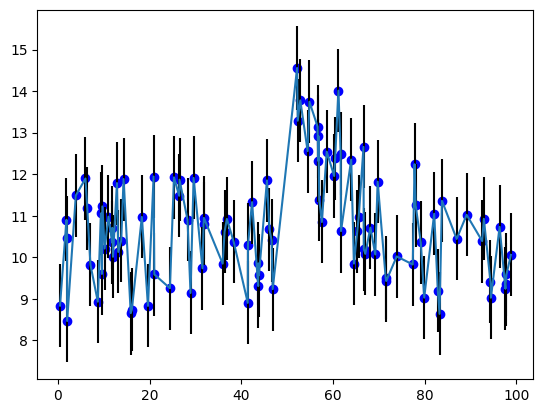

In [4]:
plt.scatter(t,flux, c='b')
plt.errorbar(t,flux, yerr=err, ecolor='k');

### Fit by eye

In [5]:
def model(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

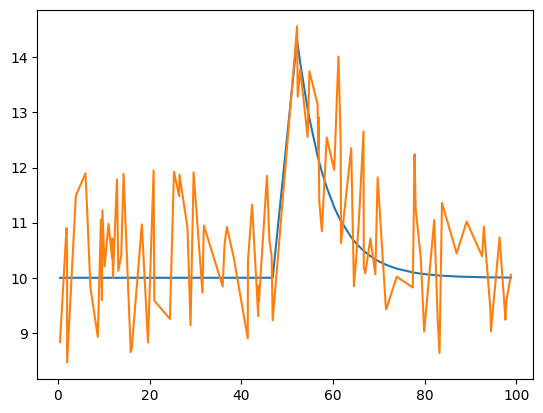

In [6]:
y=model([6,10,50,0.15],t)
plt.plot(t,y)
plt.plot(t,flux);

### MCMC

In [7]:
def LogLikelihood(theta, data, model): 
    A,b,t0,alpha=theta
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [8]:
theta=[5,10,50,0.1]
logL=LogLikelihood(theta,data,model)

In [9]:
def Logprior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 + 0.0 + 0.0 - np.log(alpha)
    return -np.inf

def logPosterior(theta, data, model):
    return LogLikelihood(theta, data, model) + Logprior(theta)

In [10]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

In [11]:
ndim = 4  
nwalkers = 20  
burn = 10000  
nsteps = 100000 

starting_guesses = np.array([6,10,50,0.15]) + 1e-1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[data, model])
sampler.run_mcmc(starting_guesses, nsteps)
 
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


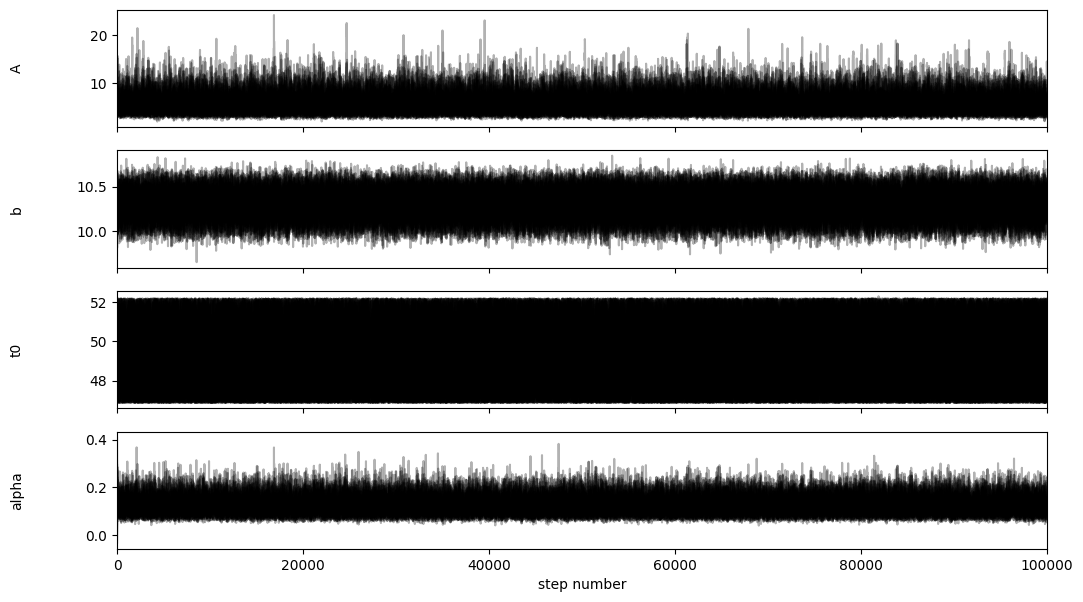

In [12]:
fig, axes = plt.subplots(4, figsize=(12, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [13]:
tau = sampler.get_autocorr_time()
print(tau)

[80.62984394 61.47412387 79.47533564 66.23971764]


In [14]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(24940, 4)


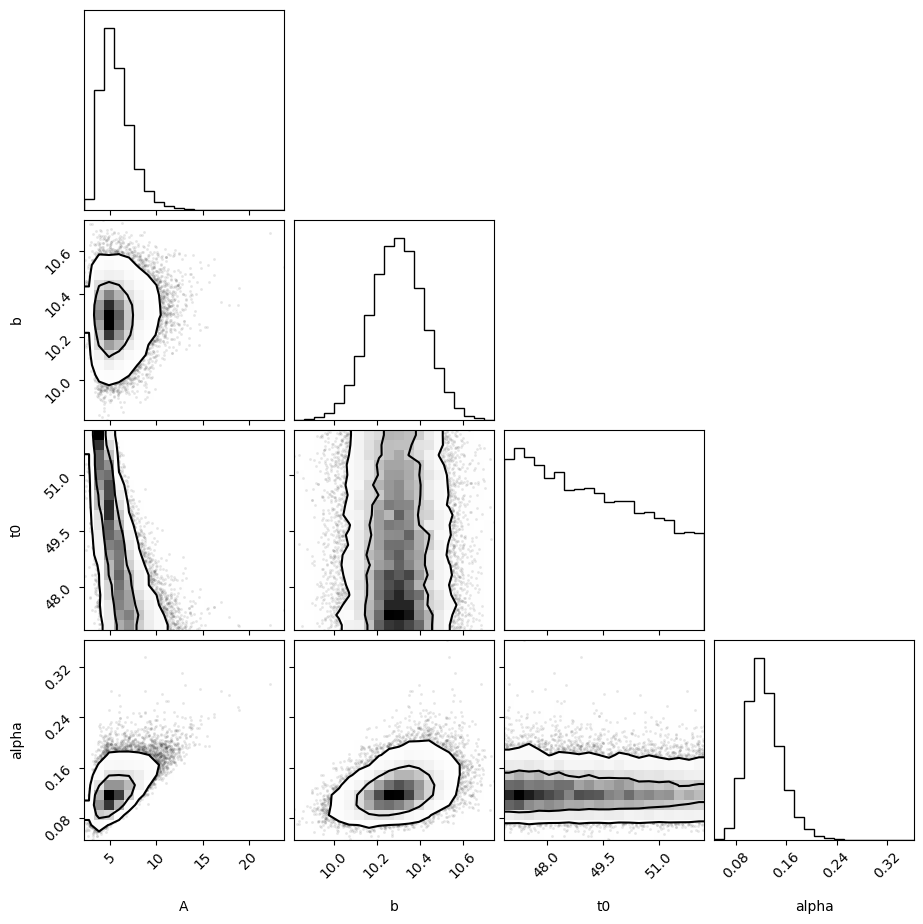

In [15]:
fig = corner.corner(
    flat_samples, labels=labels, levels=[0.68,0.95]
);

In [16]:
samples= flat_samples[np.random.choice(len(flat_samples),size=30)]

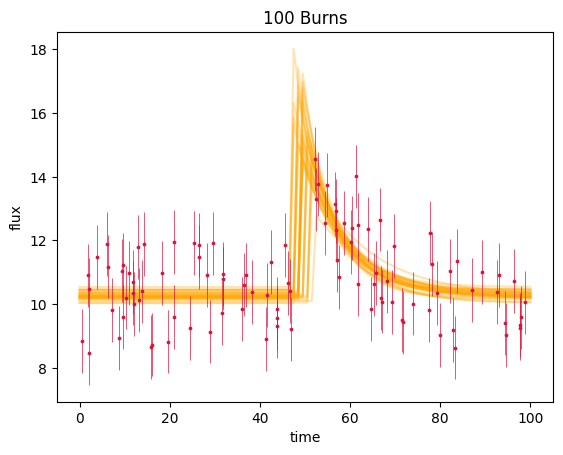

In [17]:
tgrid=np.linspace(0,100,100)

for theta in samples:

    ygrid =  model(theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='orange')
    
plt.errorbar(t,flux,yerr=err,fmt='o',c='crimson',lw=0.5, markersize=1.7)
plt.xlabel("time")
plt.ylabel("flux")
plt.title("100 Burns");

In [18]:
for i,l in enumerate(labels):
    low,med, up = np.percentile(flat_samples[:,i],[5,50,95]) 
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.401026079975344 +3.3817563669147663 -1.8016664511604947
b   10.296767402434305 +0.19876937957268304 -0.20354823040487346
t0   49.114156938099924 +2.703203070785783 -2.0403032850117526
alpha   0.1221039952328481 +0.05311456161672776 -0.03660082598647721


# L12

### Nested Sampling

In [19]:
import dynesty

### Burst

In [20]:
def Logpriornew(u):
    u[0]=u[0]*50
    u[1]=u[1]*50
    u[2]=u[2]*100
    u[3]=np.exp(u[3]*10-5)
    return u
                   
def LogPosterior(theta,data, model=model):
    return LogLikelihood(theta,data, model) + Logprior(theta)

In [21]:
def LogLikelihood(theta, model=model):
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [22]:
ndim=4

In [23]:
sampler = dynesty.NestedSampler(LogLikelihood, Logpriornew, ndim, nlive=500)
sampler.run_nested()
sresults = sampler.results

C:\Users\insta\AppData\Local\Temp\ipykernel_11760\1725545783.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
C:\Users\insta\AppData\Local\Temp\ipykernel_11760\1725545783.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
1704it [00:02, 422.06it/s, bound: 0 | nc: 9 | ncall: 16659 | eff(%): 10.229 | loglstar:   -inf < -180.800 <    inf | logz: -188.988 +/-  0.120 | dlogz: 111.578 >  0.509]C:\Users\insta\AppData\Local\Temp\ipykernel_11760\1725545783.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
C:\Users\insta\AppData\Local\Temp\ipykernel_11760\1725545783.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
1866it [00:03, 213.96it/s, bound: 2 | nc: 13 | ncall: 17724 | eff(%): 10.528 | loglstar:   -inf < -142.212 <    inf | logz: -149.959 +/-  0.118 | dlogz: 72.134 >  0.509]

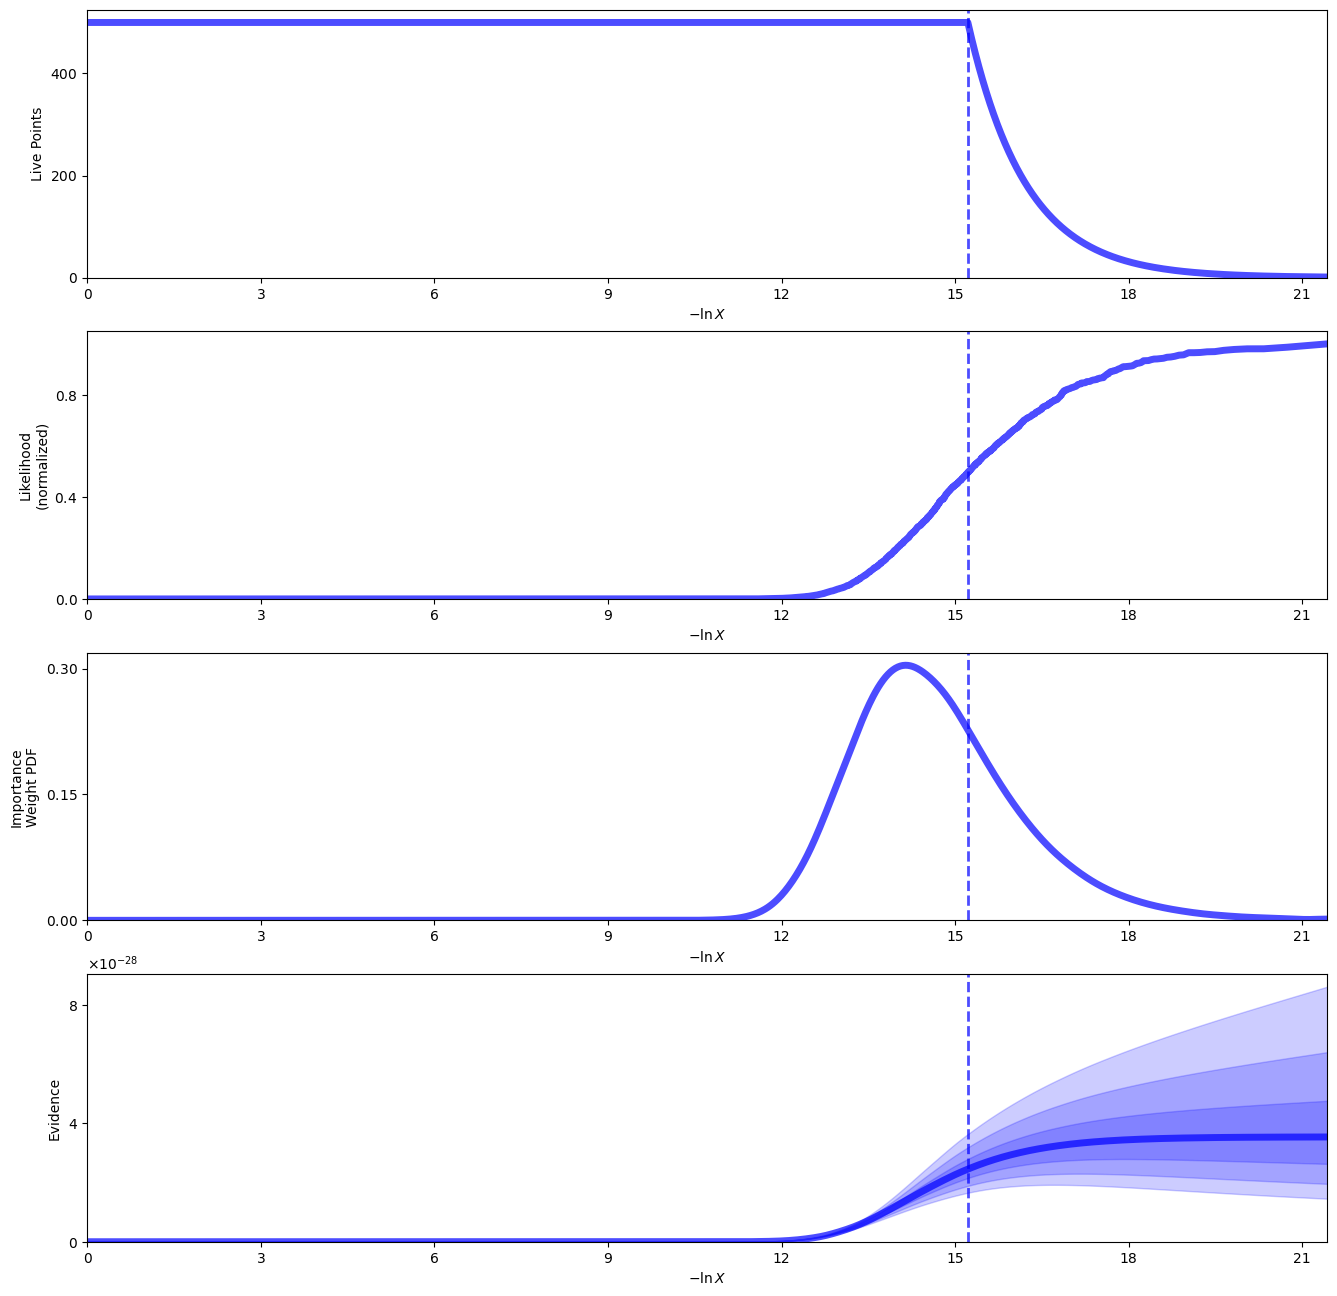

In [24]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

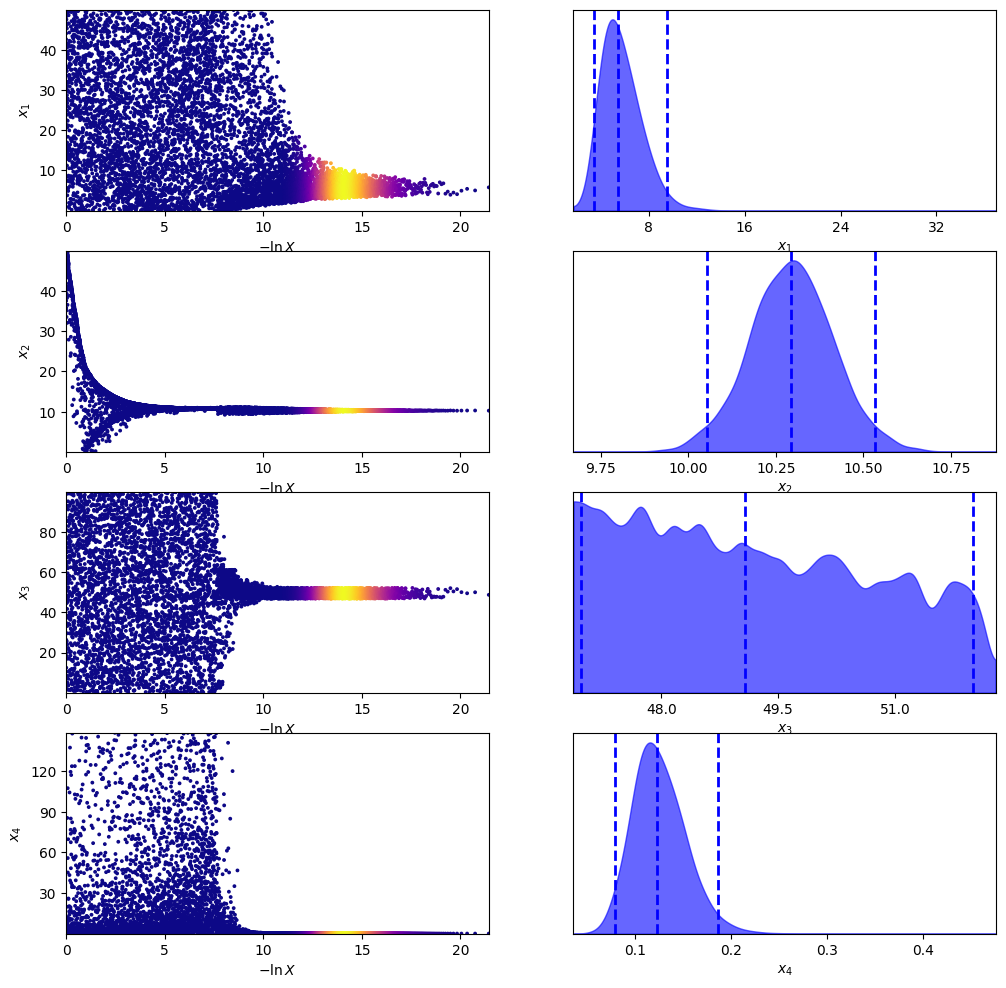

In [25]:
tfig, taxes = dyplot.traceplot(sresults)

In [26]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 3.5403895953293317e-28
68% parameter credible regions are:
 [[4.151001838114726, 7.297683884669301], [10.180646169997871, 10.409304599854355], [47.52047111066878, 51.06627801760298], [0.09957368853973575, 0.15199052944405672]]

Mean and covariance of parameters are: [ 5.71655737 10.29478961 49.22502209  0.1254181 ]
[[ 2.62701956e+00  6.55154270e-03 -1.66734174e+00  2.49610600e-02]
 [ 6.55154270e-03  1.40818424e-02  4.23683533e-04  1.14787128e-03]
 [-1.66734174e+00  4.23683533e-04  2.31638342e+00 -8.38232265e-04]
 [ 2.49610600e-02  1.14787128e-03 -8.38232265e-04  7.41406661e-04]]


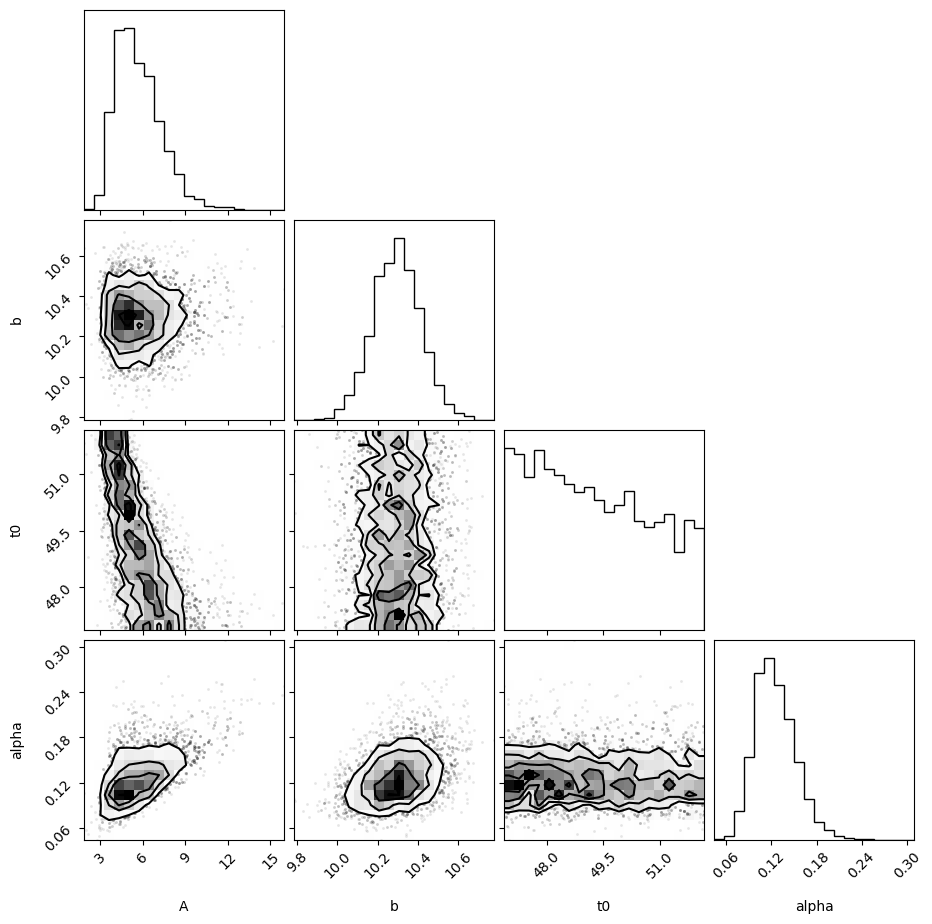

In [27]:
import corner
samples_equal = dyfunc.resample_equal(samples, weights)
labels = ["A","b","t0","alpha"]
corner.corner(samples_equal, labels=labels);

### Gaussian

In [28]:
def model(theta,t):
    A,b,t0,sigmaW=theta 
    return b+A*np.exp(-(t-t0)**2/(2*sigmaW**2))

In [29]:
def LogLikelihood(theta, model=model):
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [30]:
def Logpriornew(u):
    u[0]=u[0]*50
    u[1]=u[1]*50
    u[2]=u[2]*100
    u[3]=np.exp(u[3]*4-2)
    return u

In [31]:
sampler = dynesty.NestedSampler(LogLikelihood, Logpriornew, ndim)
sampler.run_nested()
sresults2 = sampler.results

4827it [01:29, 81.80it/s, bound: 148 | nc: 3 | ncall: 101317 | eff(%):  4.764 | loglstar:   -inf < -76.212 <    inf | logz: -87.457 +/-  0.143 | dlogz: 24.274 >  0.509]C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
8118it [01:44, 77.94it/s, +500 | bound: 170 | nc: 1 | ncall: 117355 | eff(%):  7.375 | loglstar:   -inf < -52.427 <    inf | logz: -67.930 +/-  0.175 | dlogz:  0.001 >  0.509]


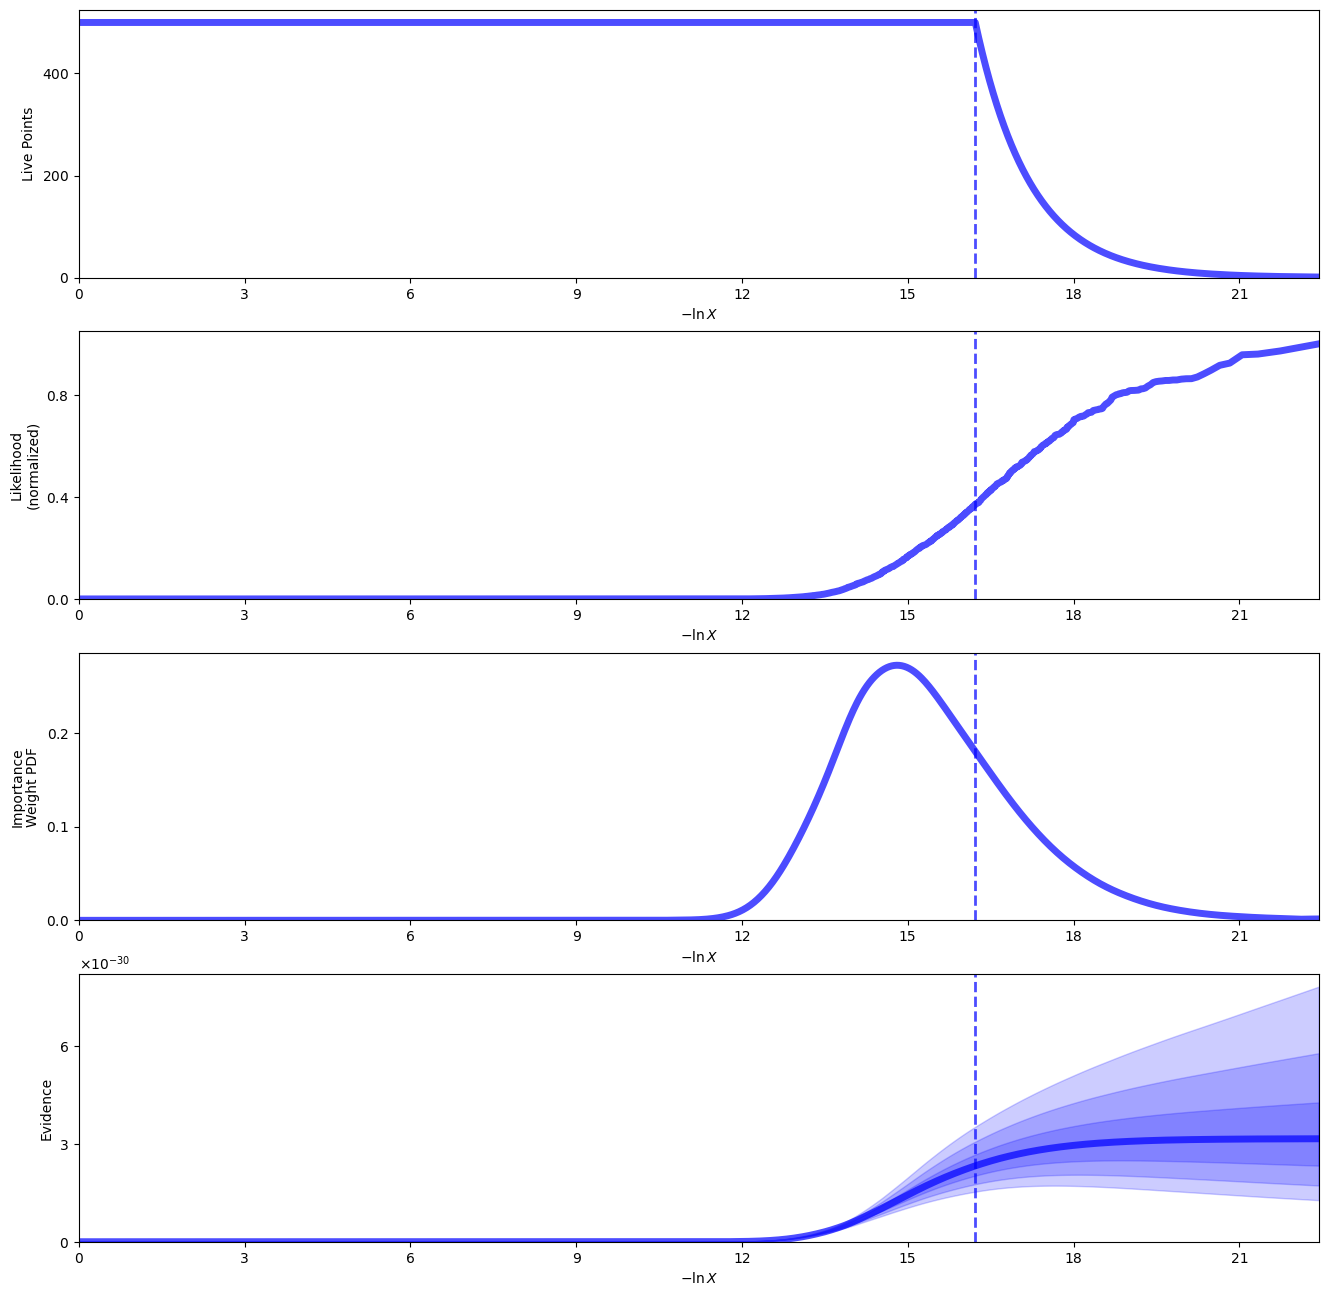

In [32]:
rfig, raxes = dyplot.runplot(sresults2)

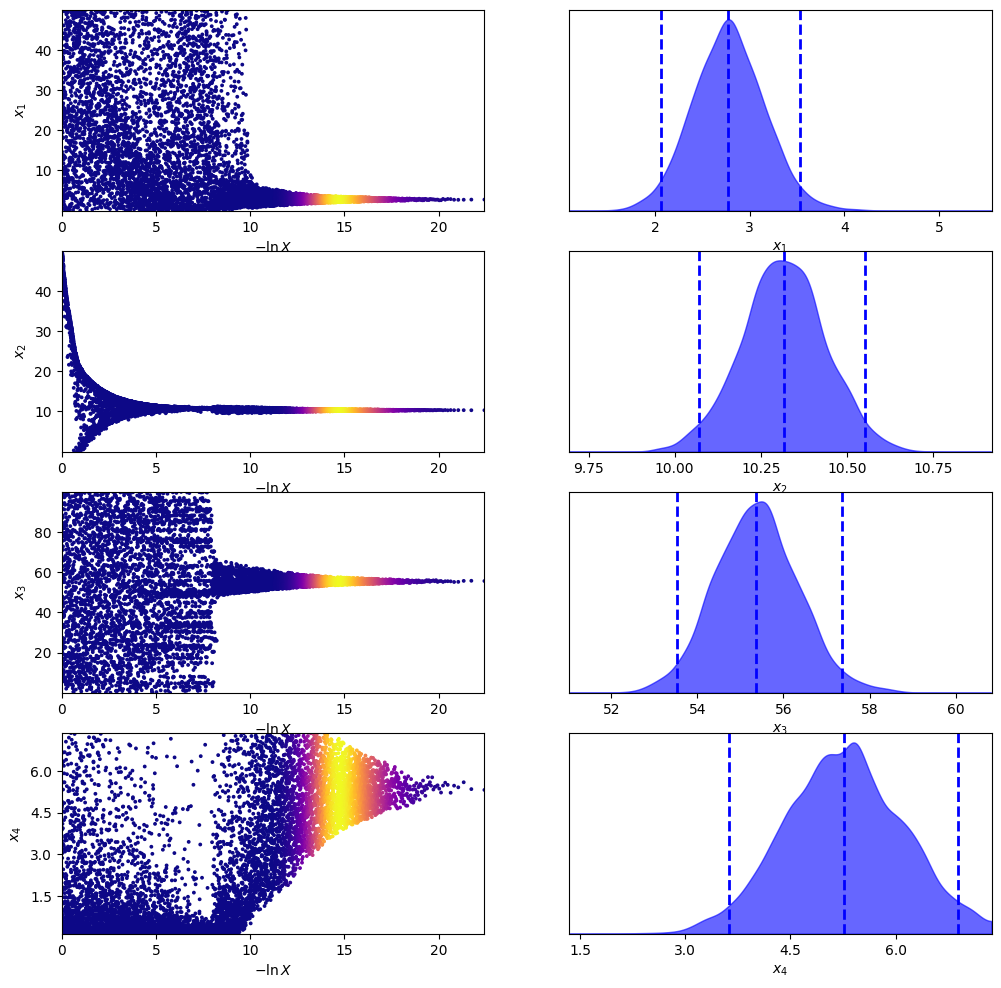

In [33]:
tfig, taxes = dyplot.traceplot(sresults2)

In [34]:
# Extract sampling results.
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights


evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 3.1518438064883644e-30
68% parameter credible regions are:
 [[2.4038604641866437, 3.138788354869229], [10.195690314316746, 10.43440477256513], [54.406947686999494, 56.327052804326065], [4.420999693765159, 6.12919299377]]

Mean and covariance of parameters are: [ 2.77825013 10.31609098 55.37576778  5.25284494]
[[ 0.14199762 -0.01044306 -0.11483945 -0.1243173 ]
 [-0.01044306  0.0146896  -0.01823396 -0.03876406]
 [-0.11483945 -0.01823396  0.94427947  0.2876253 ]
 [-0.1243173  -0.03876406  0.2876253   0.6995071 ]]


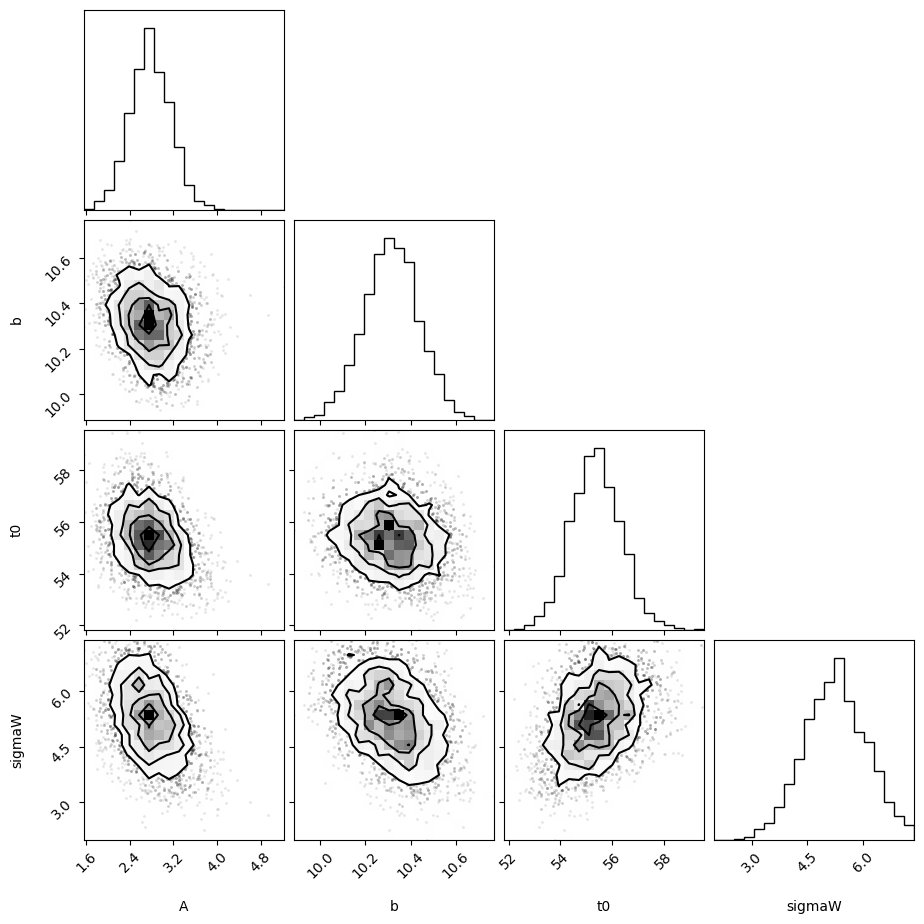

In [35]:
samples_equal = dyfunc.resample_equal(samples, weights)
labels = ["A","b","t0","sigmaW"]
corner.corner(samples_equal, labels=labels);

In [36]:
bayes_factor=np.exp(evidence)/np.exp(evidence2)
if bayes_factor > 100: print(bayes_factor,'Decisive')
elif bayes_factor > 30: print(bayes_factor,'Very strong')
elif bayes_factor > 10: print(bayes_factor,'Strong')
elif bayes_factor > 3: print(bayes_factor,'Substantial')
elif bayes_factor > 1: print(bayes_factor,'Barely worth mentioning')
else: print('Negative')

112.32757118360718 Decisive
